In [1]:
import matplotlib.pyplot as plt
import skimage.io as io
import cv2

from pathlib import Path
import numpy as np
from scipy.spatial.distance import cdist


import torch
from hloc import extractors
from hloc.extract_features import confs, ImageDataset, dynamic_load


# Load images

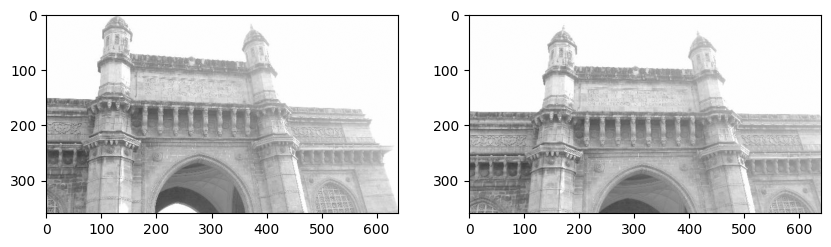

In [2]:
goi1, goi2 = io.imread("img/goi1.jpg"), io.imread("img/goi2.jpg")
fig, ax = plt.subplots(1, 2, figsize=(10, 10))
plt.gray()

ax[0].imshow(goi1, vmin=0, vmax=255)
ax[1].imshow(goi2, vmin=0, vmax=255)

## Harris Heatmap (1988)
$$ R = \det(M) - k \cdot \mathrm{trace}(M)$$

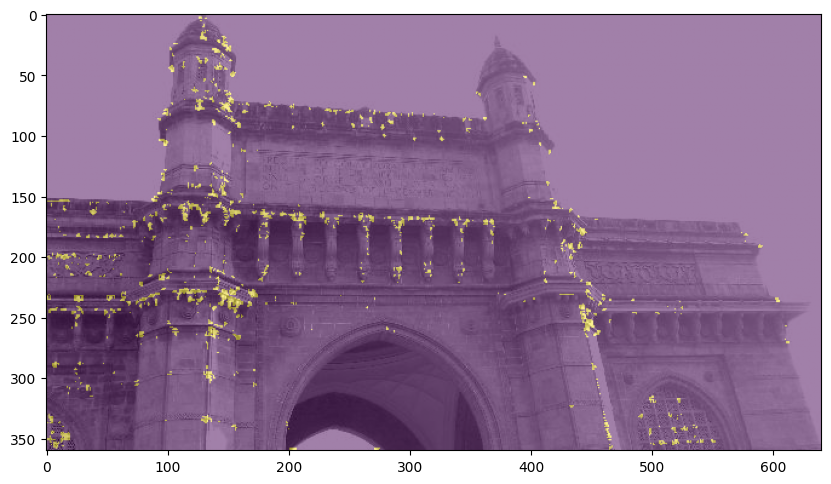

In [3]:
harris = cv2.cornerHarris(goi1, blockSize=3, ksize=5, k=0.04)

fig = plt.figure(figsize=(10, 10))
plt.imshow(goi1)
plt.imshow(harris > 0.01 * harris.max(), cmap="viridis", alpha=0.5);

## Shi-Tomasi (1994)
$$ R = \min(\lambda_1, \lambda_2) $$

Improved local maxima heuristics, number of detected keypoints, and more

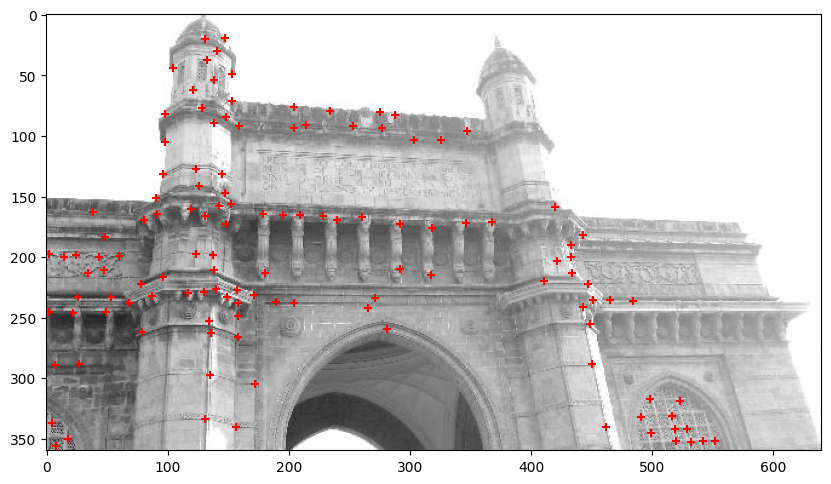

In [4]:
kp = cv2.goodFeaturesToTrack(goi1, 125, 0.001, 10)[:, 0, :]
fig = plt.figure(figsize=(10, 10))
plt.imshow(goi1)
plt.scatter(kp[:, 0], kp[:, 1], marker="+", c="r");

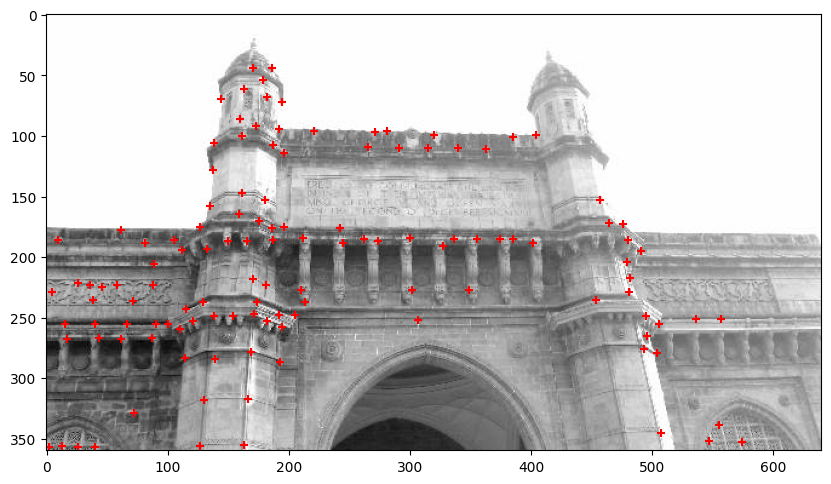

In [5]:
kp = cv2.goodFeaturesToTrack(goi2, 125, 0.001, 10)[:, 0, :]
fig = plt.figure(figsize=(10, 10))
plt.imshow(goi2)
plt.scatter(kp[:, 0], kp[:, 1], marker="+", c="r");

## SIFT (1999)

Adds Scale-invariance to kp detection
Provides a way to ``describe'' each keypoint, from stats around it.

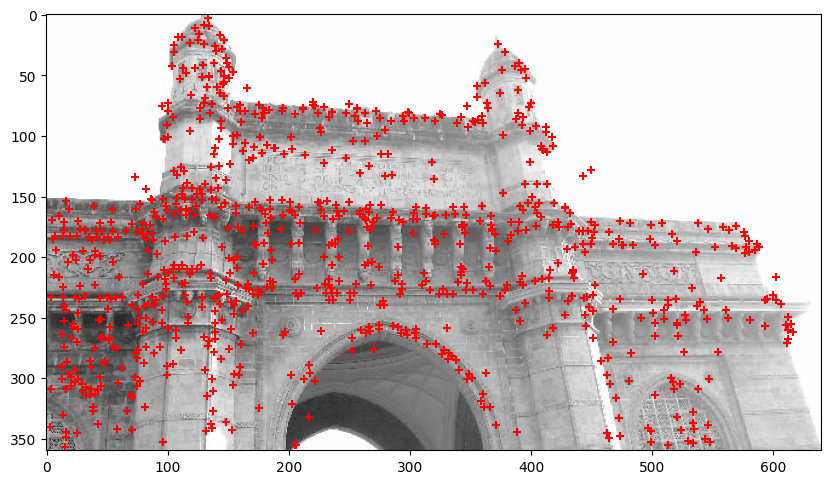

In [6]:
sift = cv2.SIFT_create()
kp1, descriptors_1 = sift.detectAndCompute(goi1, None)
kp1 = np.array([p.pt for p in kp1])

fig = plt.figure(figsize=(10, 10))
plt.imshow(goi1)
plt.scatter(kp1[:, 0], kp1[:, 1], marker="+", c="r");

In [7]:
descriptors_1.shape

(1051, 128)

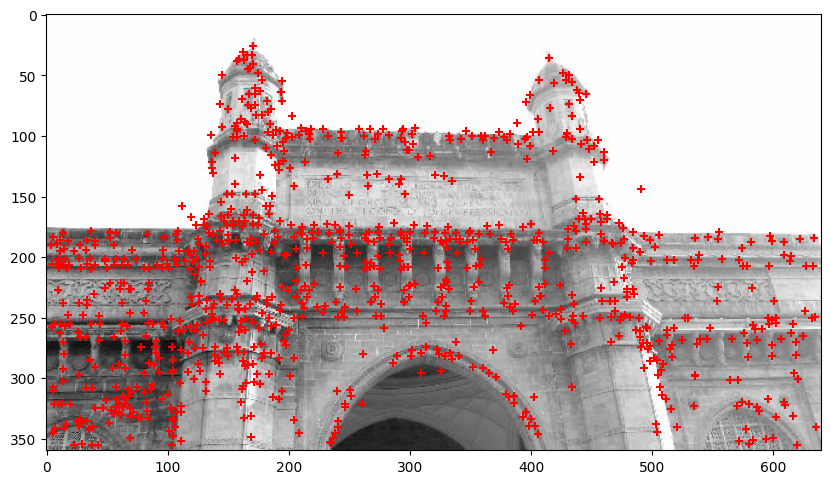

In [8]:
sift = cv2.SIFT_create()
kp2, descriptors_2 = sift.detectAndCompute(goi2, None)
kp2 = np.array([p.pt for p in kp2])

fig = plt.figure(figsize=(10, 10))
plt.imshow(goi2)
plt.scatter(kp2[:, 0], kp2[:, 1], marker="+", c="r");

In [9]:
descriptors_2.shape

(1134, 128)

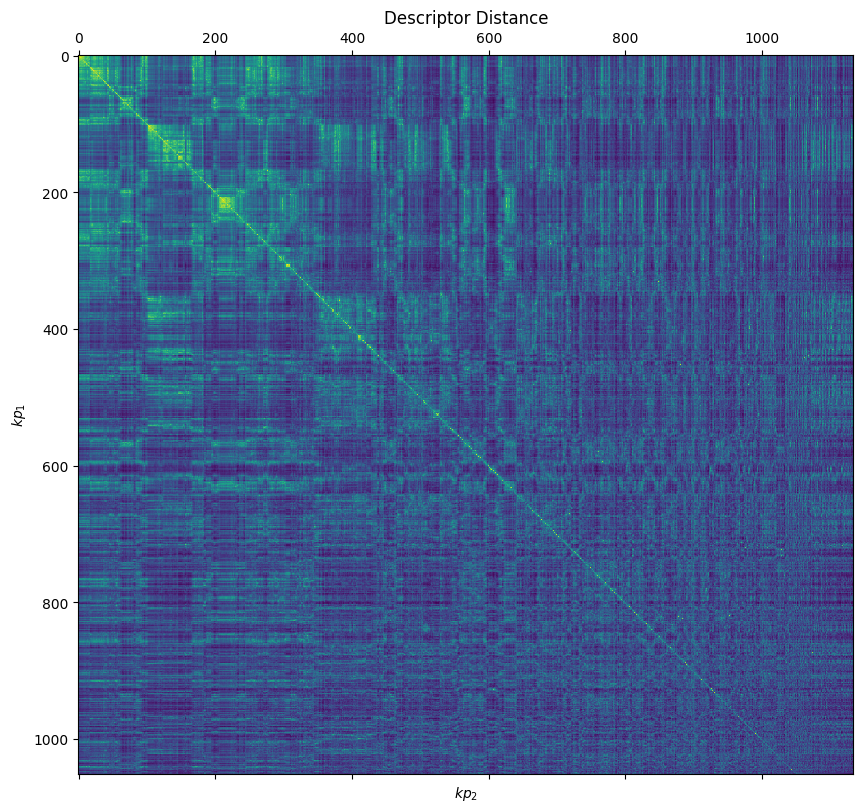

In [10]:
cross_distance = cdist(descriptors_1, descriptors_2)

def sort_matrix(d):
    for i in range(min(d.shape)):
        fixed = np.arange(i)
        d = d[:, np.r_[fixed, i + np.argsort(d[i, i:])]]
        d = d[np.r_[fixed, i + np.argsort(d[i:, i])], :]
    return d



fig = plt.figure(figsize=(10, 10))
plt.matshow(-sort_matrix(cross_distance), fignum=1, cmap="viridis");
plt.ylabel("$kp_1$")
plt.xlabel("$kp_2$");
plt.title("Descriptor Distance");

In [11]:
conf = confs["superpoint_inloc"]

In [12]:
dataset = ImageDataset(Path("img/"), conf["preprocessing"], paths=["goi1.jpg", "goi2.jpg"])

device = "cuda" if torch.cuda.is_available() else "cpu"
Model = dynamic_load(extractors, conf["model"]["name"])
model = Model(conf["model"]).eval().to(device)
loader = torch.utils.data.DataLoader(
    dataset, num_workers=1, shuffle=False, pin_memory=True
)

Loaded SuperPoint model


In [13]:
preds = {}
with torch.no_grad():
    for idx, data in enumerate(loader):
        name = dataset.names[idx]
        pred = model({"image": data["image"].to(device, non_blocking=True)})
        pred = {k: v[0].cpu().numpy() for k, v in pred.items()}
        pred["image"] = data["image"][0, 0].cpu().numpy() 
        preds[name] = pred

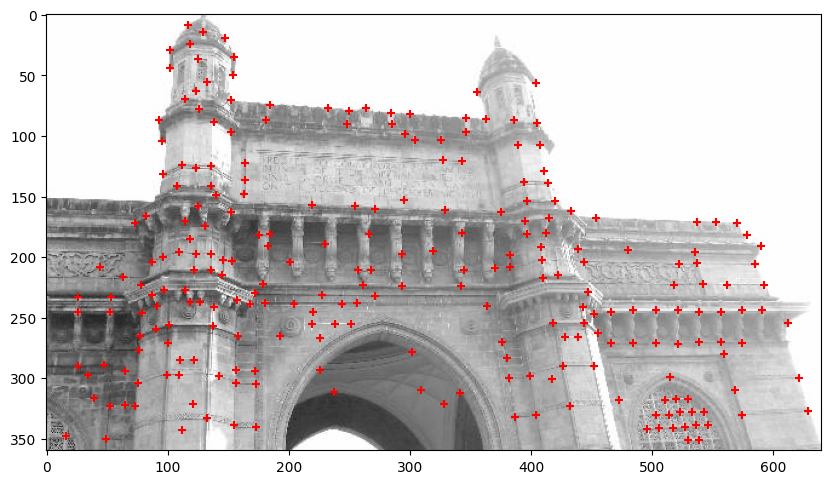

In [14]:
fig = plt.figure(figsize=(10, 10))
pred = preds["goi1.jpg"]
kps    = pred["keypoints"]
scores = pred["scores"]

selected = np.argsort(scores)[-250:] # select top points
kps = kps[selected]

plt.imshow(pred["image"])
plt.scatter(kps[:, 0], kps[:, 1], marker="+", c="r");

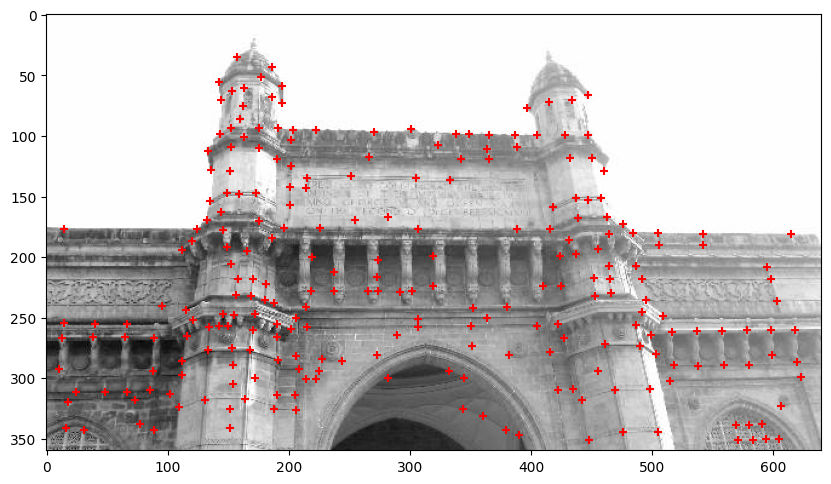

In [15]:
fig = plt.figure(figsize=(10, 10))
pred = preds["goi2.jpg"]
kps    = pred["keypoints"]
scores = pred["scores"]

selected = np.argsort(scores)[-250:] # select top points
kps = kps[selected]

plt.imshow(pred["image"])
plt.scatter(kps[:, 0], kps[:, 1], marker="+", c="r");

In [16]:
preds["goi2.jpg"]["descriptors"].shape

(256, 771)

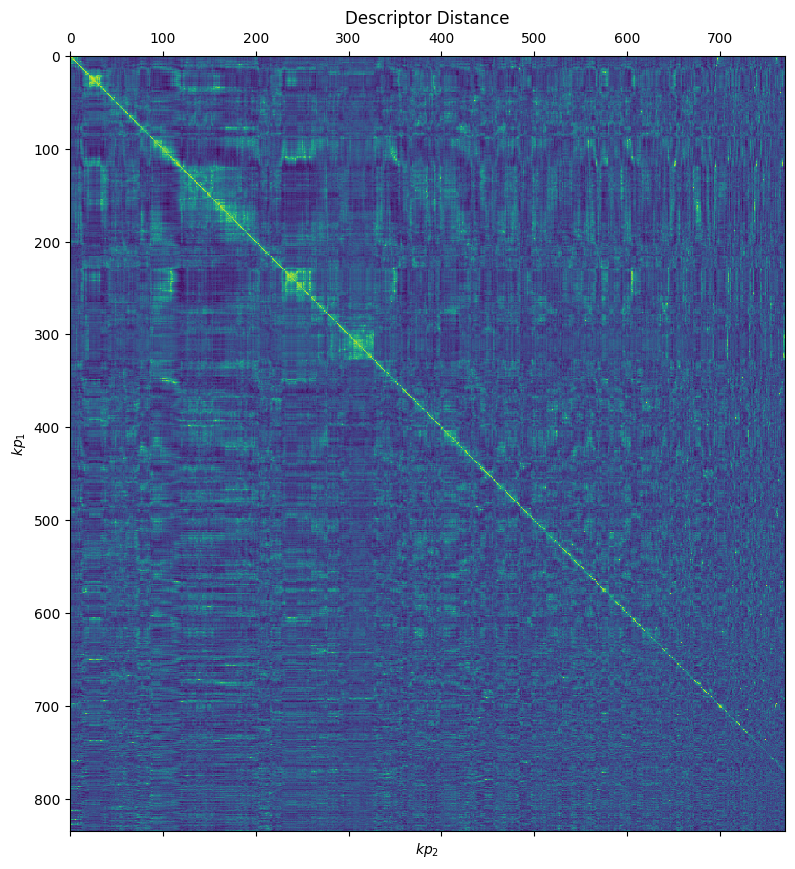

In [17]:
cross_distance = cdist(preds["goi1.jpg"]["descriptors"].T, preds["goi2.jpg"]["descriptors"].T)
fig = plt.figure(figsize=(10, 10))
plt.matshow(-sort_matrix(cross_distance), fignum=1, cmap="viridis");
plt.ylabel("$kp_1$")
plt.xlabel("$kp_2$");
plt.title("Descriptor Distance");